In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error,mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import joblib


In [86]:
df = pd.read_csv('../data/Life_Expectancy_Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# EDA

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [88]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [89]:
# remove rows with any missing values and reset index
before = df.shape[0]
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
after = df.shape[0]

print(f"Dropped {before - after} rows with missing values — new shape: {df.shape}")
# quick check
df.isnull().sum()

Dropped 1289 rows with missing values — new shape: (1649, 22)


Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

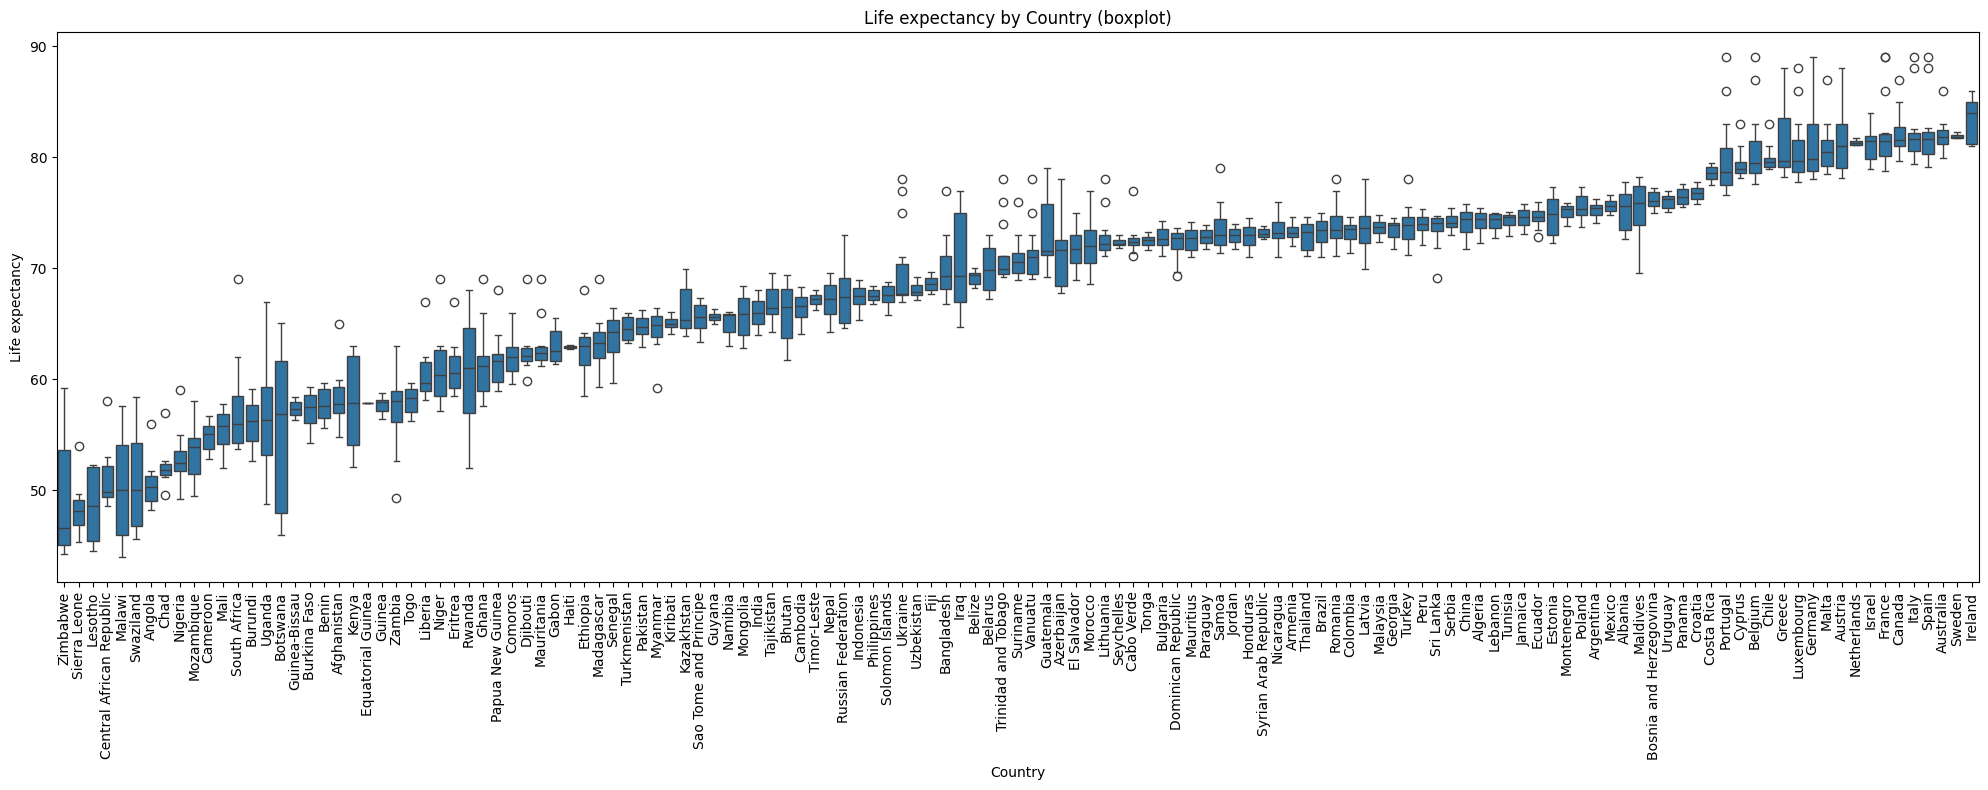

In [90]:
plt.figure(figsize=(20,8))
order = df.groupby('Country')['Life expectancy '].median().sort_values().index
sns.boxplot(x='Country', y='Life expectancy ', data=df, order=order)
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('Life expectancy')
plt.title('Life expectancy by Country (boxplot)')
plt.tight_layout()
plt.show()

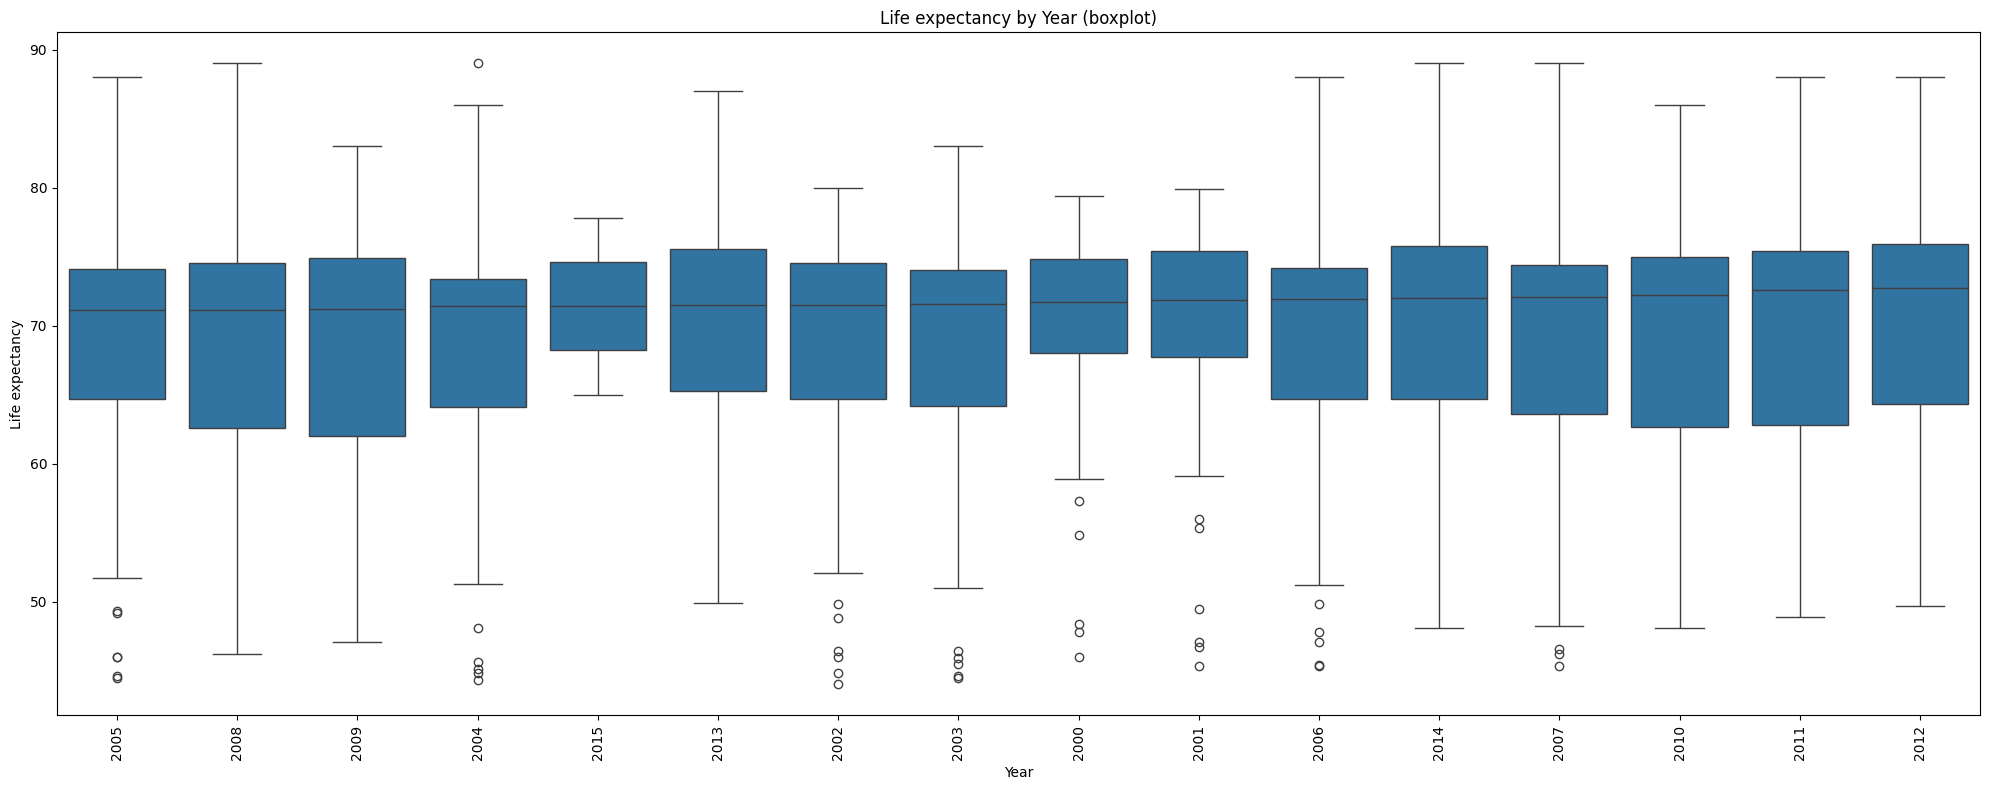

In [91]:
plt.figure(figsize=(20,8))
order = df.groupby('Year')['Life expectancy '].median().sort_values().index
sns.boxplot(x='Year', y='Life expectancy ', data=df, order=order)
plt.xticks(rotation=90)
plt.xlabel('Year')
plt.ylabel('Life expectancy')
plt.title('Life expectancy by Year (boxplot)')
plt.tight_layout()
plt.show()

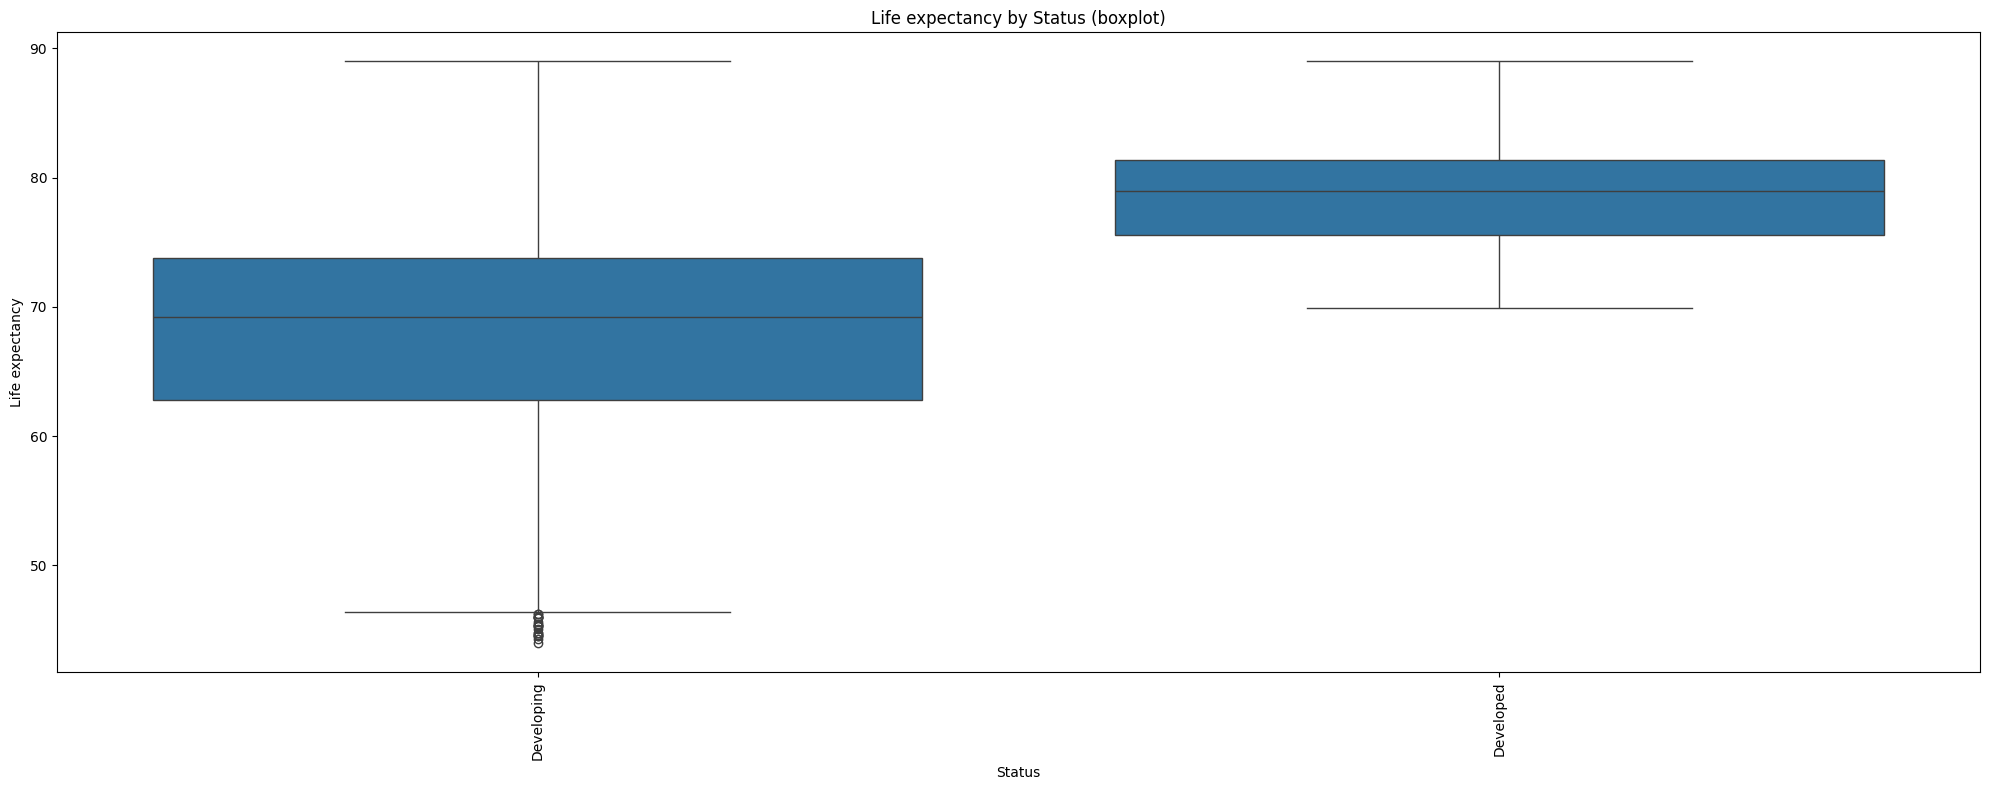

In [92]:
plt.figure(figsize=(20,8))
order = df.groupby('Status')['Life expectancy '].median().sort_values().index
sns.boxplot(x='Status', y='Life expectancy ', data=df, order=order)
plt.xticks(rotation=90)
plt.xlabel('Status')
plt.ylabel('Life expectancy')
plt.title('Life expectancy by Status (boxplot)')
plt.tight_layout()
plt.show()

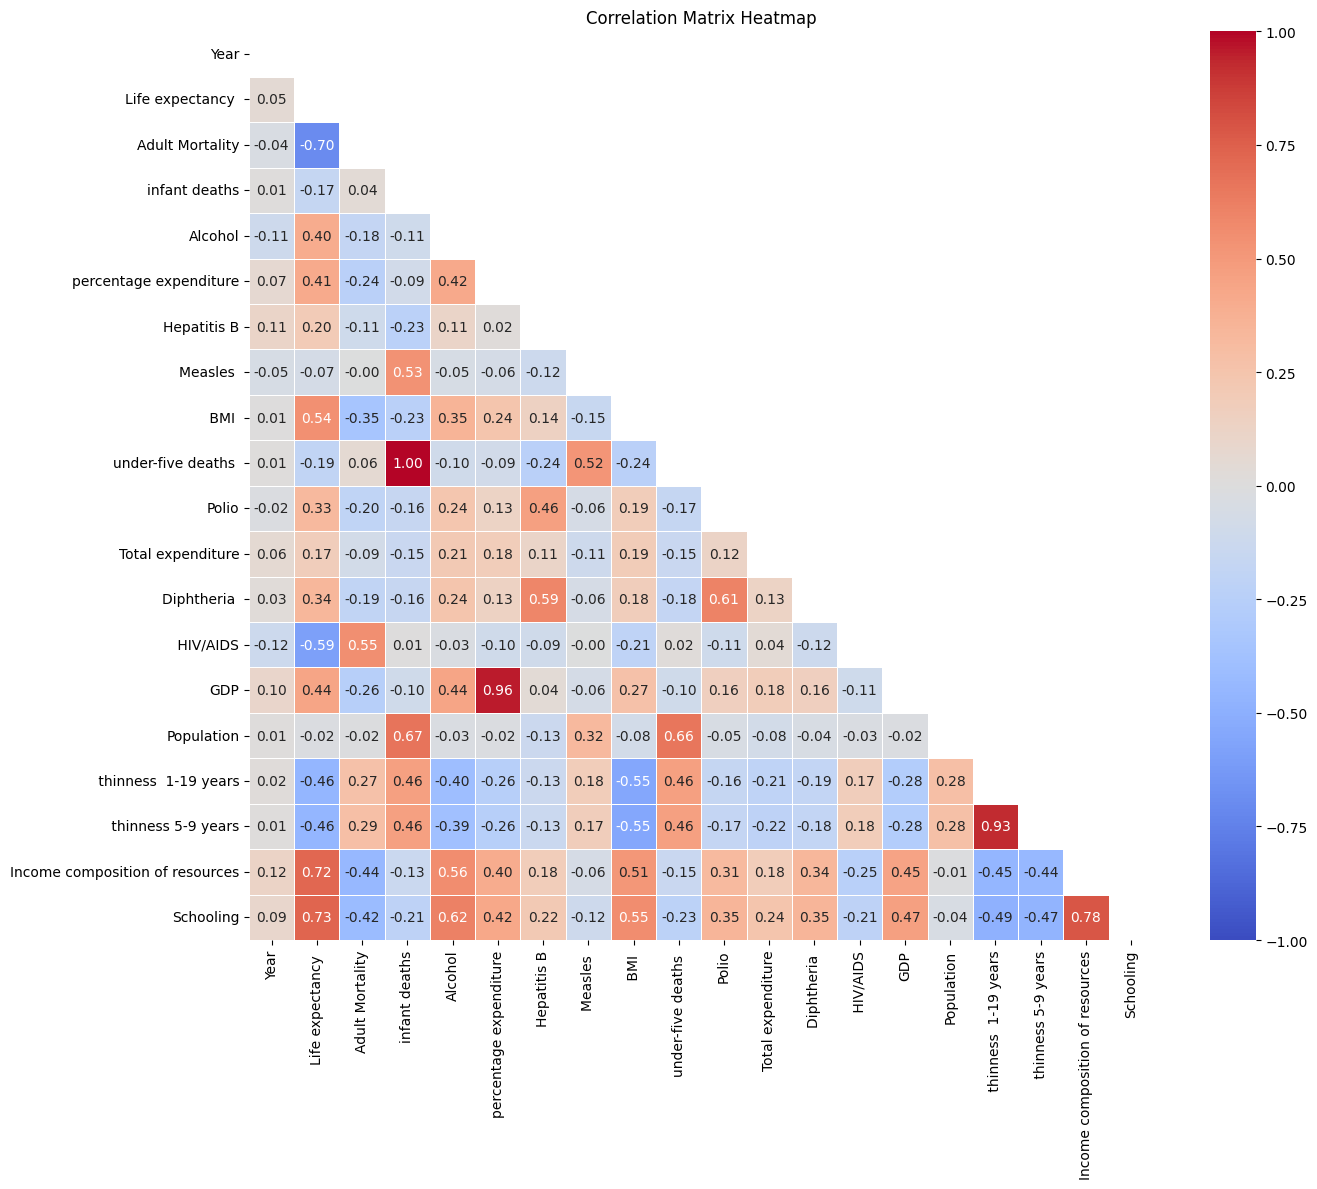

In [93]:
plt.figure(figsize=(14,12))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

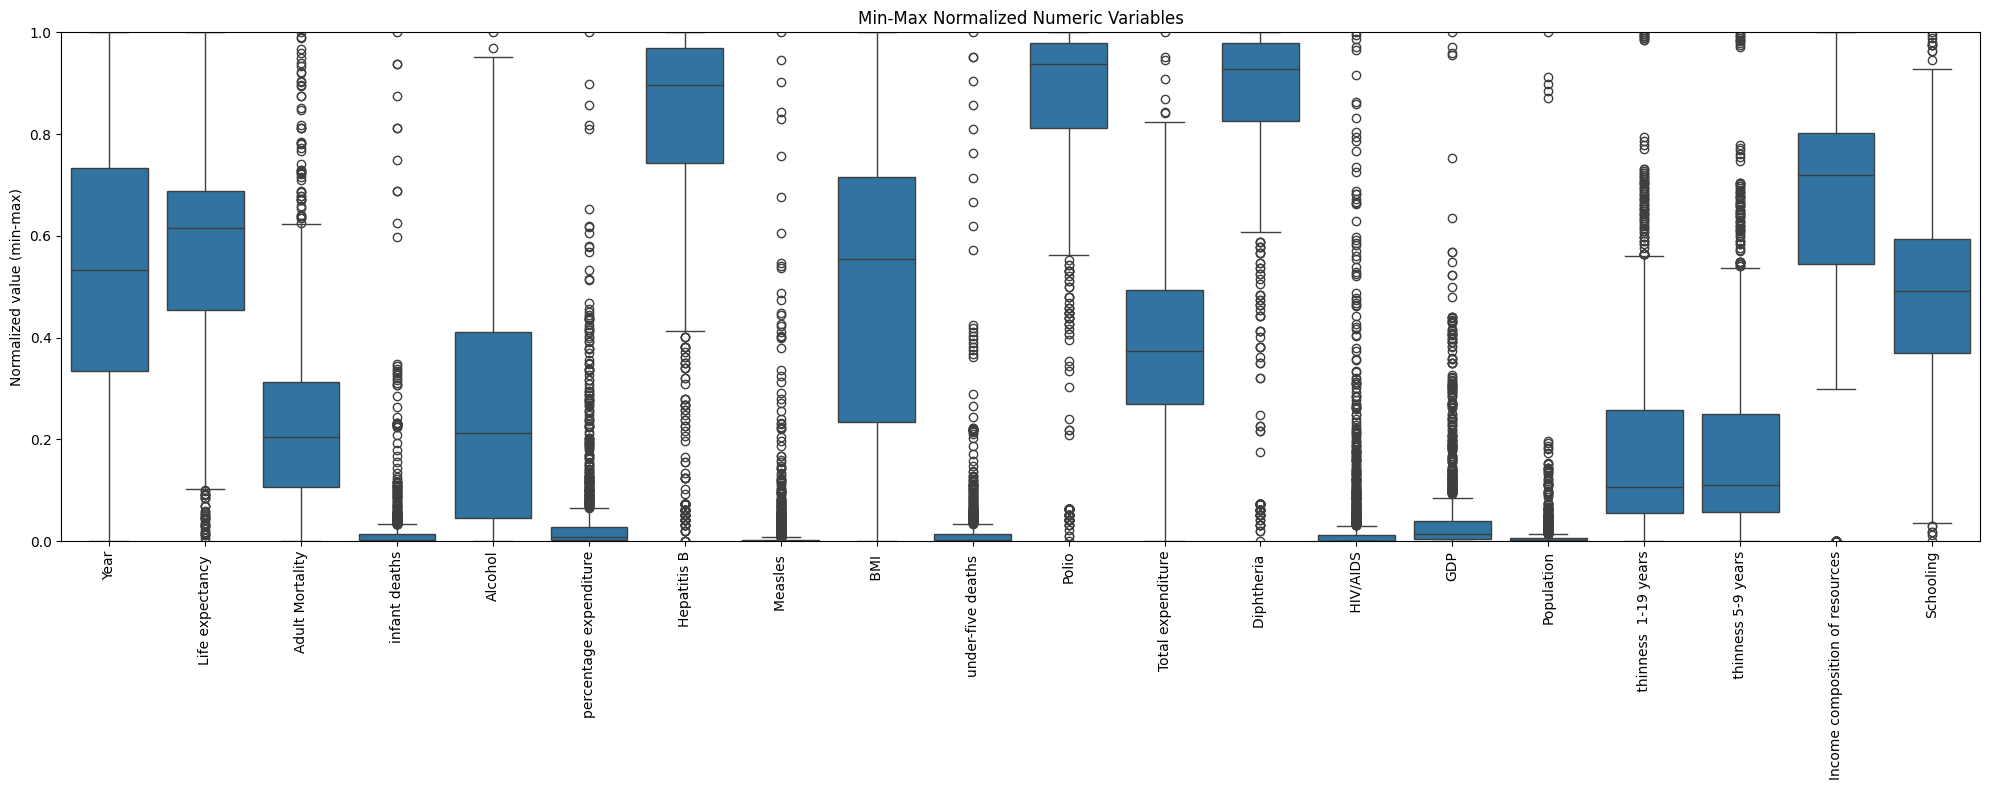

In [94]:
# min-max normalize numeric columns and plot distributions
numeric_cols = df.select_dtypes(include=[np.number]).columns
normalized = (df[numeric_cols] - df[numeric_cols].min()) / (df[numeric_cols].max() - df[numeric_cols].min())
normalized = normalized.fillna(0)

plt.figure(figsize=(20,8))
melted = normalized.melt(var_name='variable', value_name='value')
sns.boxplot(x='variable', y='value', data=melted)
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.xlabel('')
plt.ylabel('Normalized value (min-max)')
plt.title('Min-Max Normalized Numeric Variables')
plt.tight_layout()
plt.show()

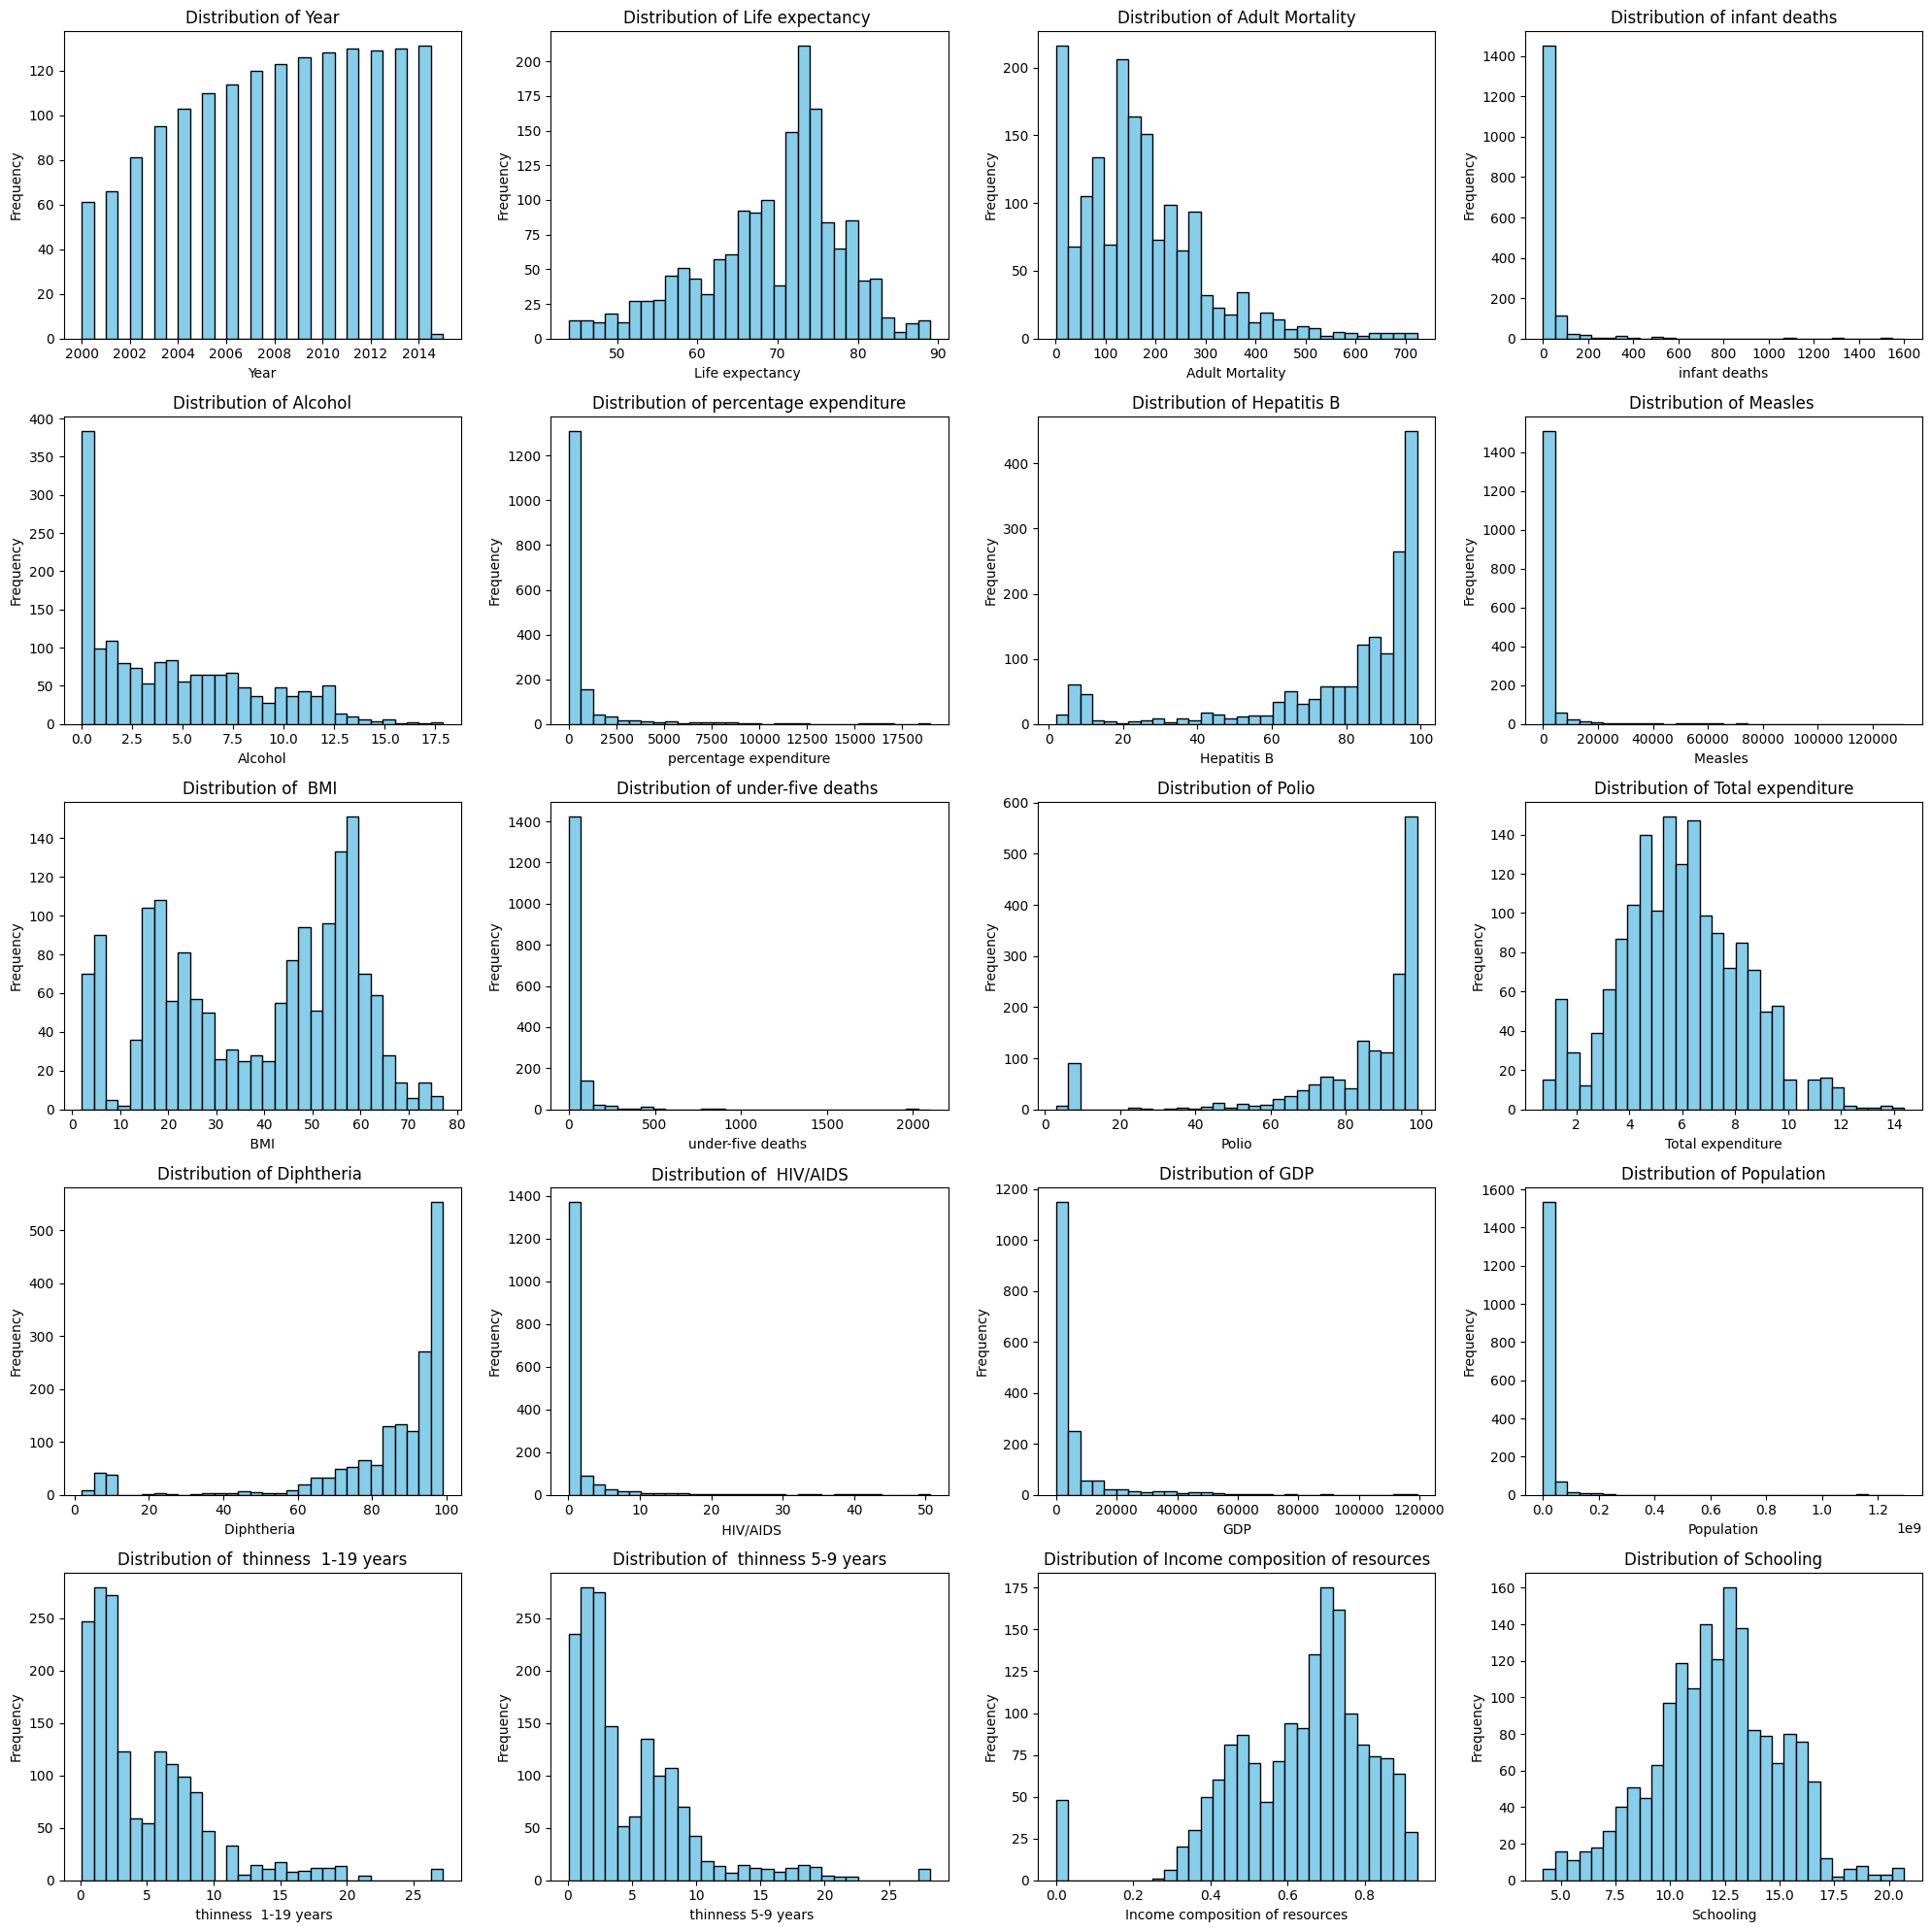

In [95]:
# Create histograms for all numeric variables
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [96]:
df[numeric_cols].skew()

Year                               -0.200171
Life expectancy                    -0.628758
Adult Mortality                     1.276429
infant deaths                       8.477369
Alcohol                             0.662518
percentage expenditure              4.980574
Hepatitis B                        -1.793377
Measles                             7.957838
 BMI                               -0.233601
under-five deaths                   8.340863
Polio                              -2.360177
Total expenditure                   0.213362
Diphtheria                         -2.487492
 HIV/AIDS                           4.974176
GDP                                 4.517297
Population                         14.186299
 thinness  1-19 years               1.821074
 thinness 5-9 years                 1.866980
Income composition of resources    -1.155244
Schooling                          -0.128164
dtype: float64

# Data Preprocessing

In [97]:
skewed_cols = df[numeric_cols].skew()
high_skew = skewed_cols[(skewed_cols > 1) | (skewed_cols < -1)].index
high_skew = high_skew.drop(['Hepatitis B', 'Polio', 'Diphtheria ', 'Income composition of resources',' thinness  1-19 years',' thinness 5-9 years'])
for col in high_skew:
    print(col)
    df[f'scale_{col}'] = np.log1p(df[col])
    if df[f'scale_{col}'].skew() > 1 or df[f'scale_{col}'].skew() < -1:
        print(f'Log1p did not reduce skewness for {col}, trying Square Root')
        sqrt = np.sqrt(df[col])
        bc = boxcox(df[col].dropna() + 1)
        if sqrt.skew() < 1 and sqrt.skew() > -1:
            df[f'scale_{col}'] = sqrt
        elif pd.Series(bc[0]).skew() < 1 and pd.Series(bc[0]).skew() > -1:
            df[f'scale_{col}'] = bc[0]
        else:
            print(f'Neither transformation reduced skewness for {col}')

Adult Mortality
Log1p did not reduce skewness for Adult Mortality, trying Square Root
infant deaths
percentage expenditure
Measles 
under-five deaths 
 HIV/AIDS
Log1p did not reduce skewness for  HIV/AIDS, trying Square Root
GDP
Population


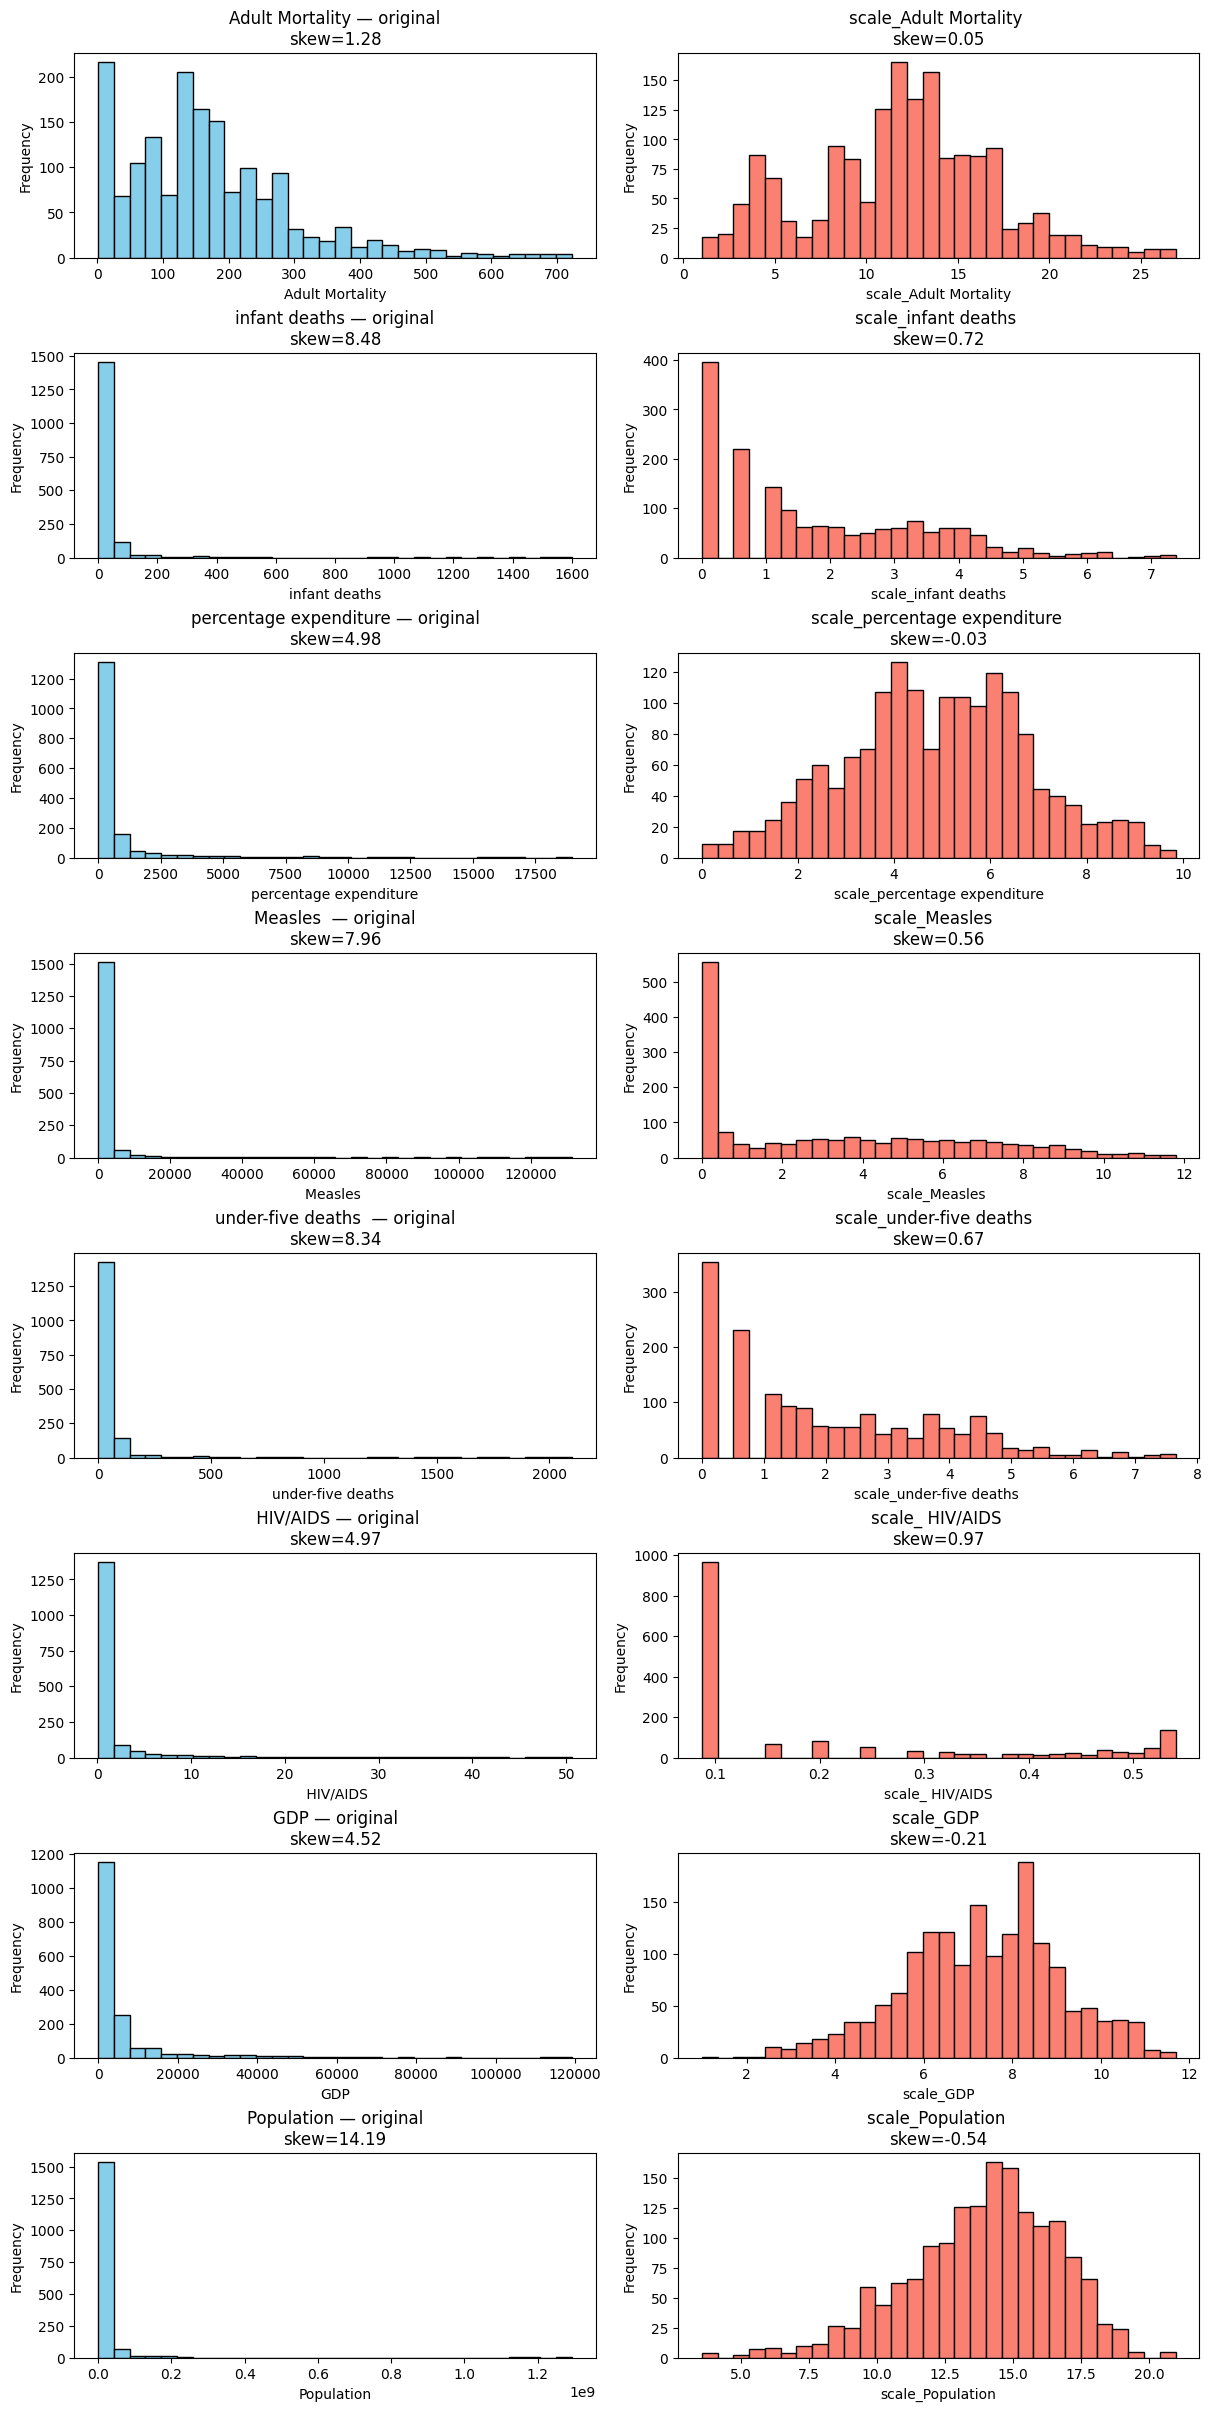

In [98]:
# side-by-side histograms: original vs log1p_ version for all high-skew columns
cols = high_skew.tolist()
n = len(cols)

fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n), constrained_layout=True)
if n == 1:
    axes = axes.reshape(1, 2)

for i, col in enumerate(cols):
    orig = df[col].dropna()
    logcol = f'scale_{col}'
    logv = df[logcol].dropna()

    axes[i, 0].hist(orig, bins=30, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f"{col} — original\nskew={orig.skew():.2f}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    axes[i, 1].hist(logv, bins=30, color='salmon', edgecolor='black')
    axes[i, 1].set_title(f"{logcol} \nskew={logv.skew():.2f}")
    axes[i, 1].set_xlabel(logcol)
    axes[i, 1].set_ylabel('Frequency')

plt.show()

In [99]:
non_skew_numeric = numeric_cols.difference(high_skew).tolist()
scaled_cols = [f"scale_{c}" for c in high_skew if f"scale_{c}" in df.columns]

selected_cols = non_skew_numeric + scaled_cols

df_selected = df[selected_cols].copy()
df_selected.drop(['Year'], axis=1, inplace=True)
df_selected.skew()

 BMI                              -0.233601
 thinness  1-19 years              1.821074
 thinness 5-9 years                1.866980
Alcohol                            0.662518
Diphtheria                        -2.487492
Hepatitis B                       -1.793377
Income composition of resources   -1.155244
Life expectancy                   -0.628758
Polio                             -2.360177
Schooling                         -0.128164
Total expenditure                  0.213362
scale_Adult Mortality              0.054363
scale_infant deaths                0.718501
scale_percentage expenditure      -0.025151
scale_Measles                      0.560259
scale_under-five deaths            0.666207
scale_ HIV/AIDS                    0.965431
scale_GDP                         -0.212049
scale_Population                  -0.544872
dtype: float64

In [100]:
df_selected_outliers = df_selected.copy()
for col in df_selected.columns:
    lower = df_selected[col].quantile(0.01)
    upper = df_selected[col].quantile(0.99)
    df_selected_outliers[col] = df_selected[col].clip(lower, upper)

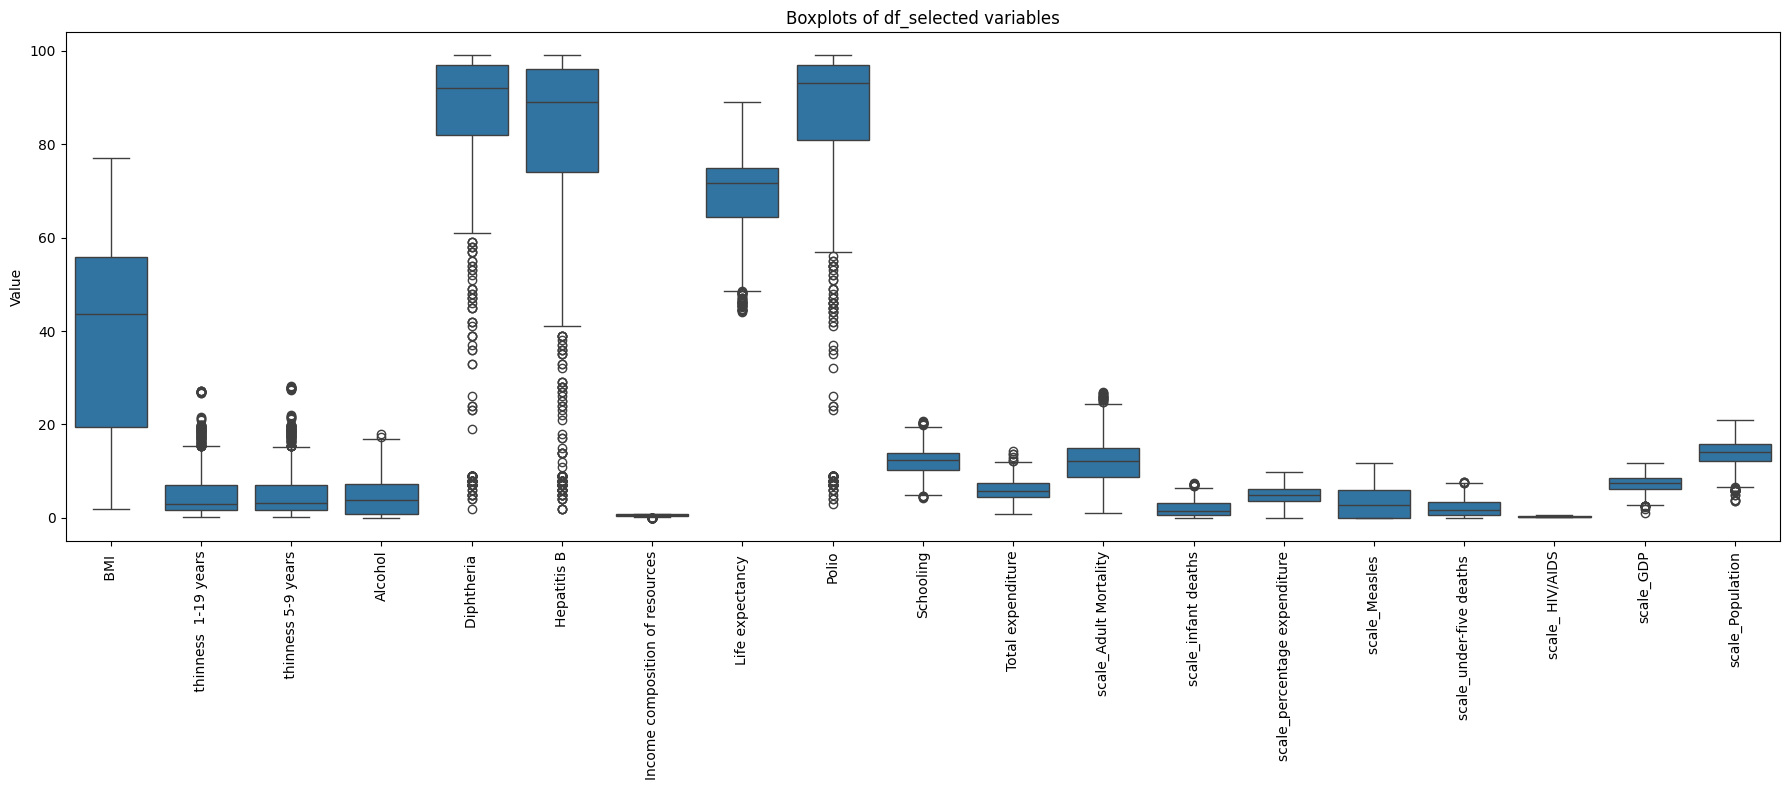

In [101]:
# boxplots for numeric columns in df_selected
num_cols = df_selected.select_dtypes(include=[np.number]).columns
melted = df_selected[num_cols].melt(var_name='variable', value_name='value')

plt.figure(figsize=(18, 8))
sns.boxplot(x='variable', y='value', data=melted)
plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('Value')
plt.title('Boxplots of df_selected variables')
plt.tight_layout()
plt.show()

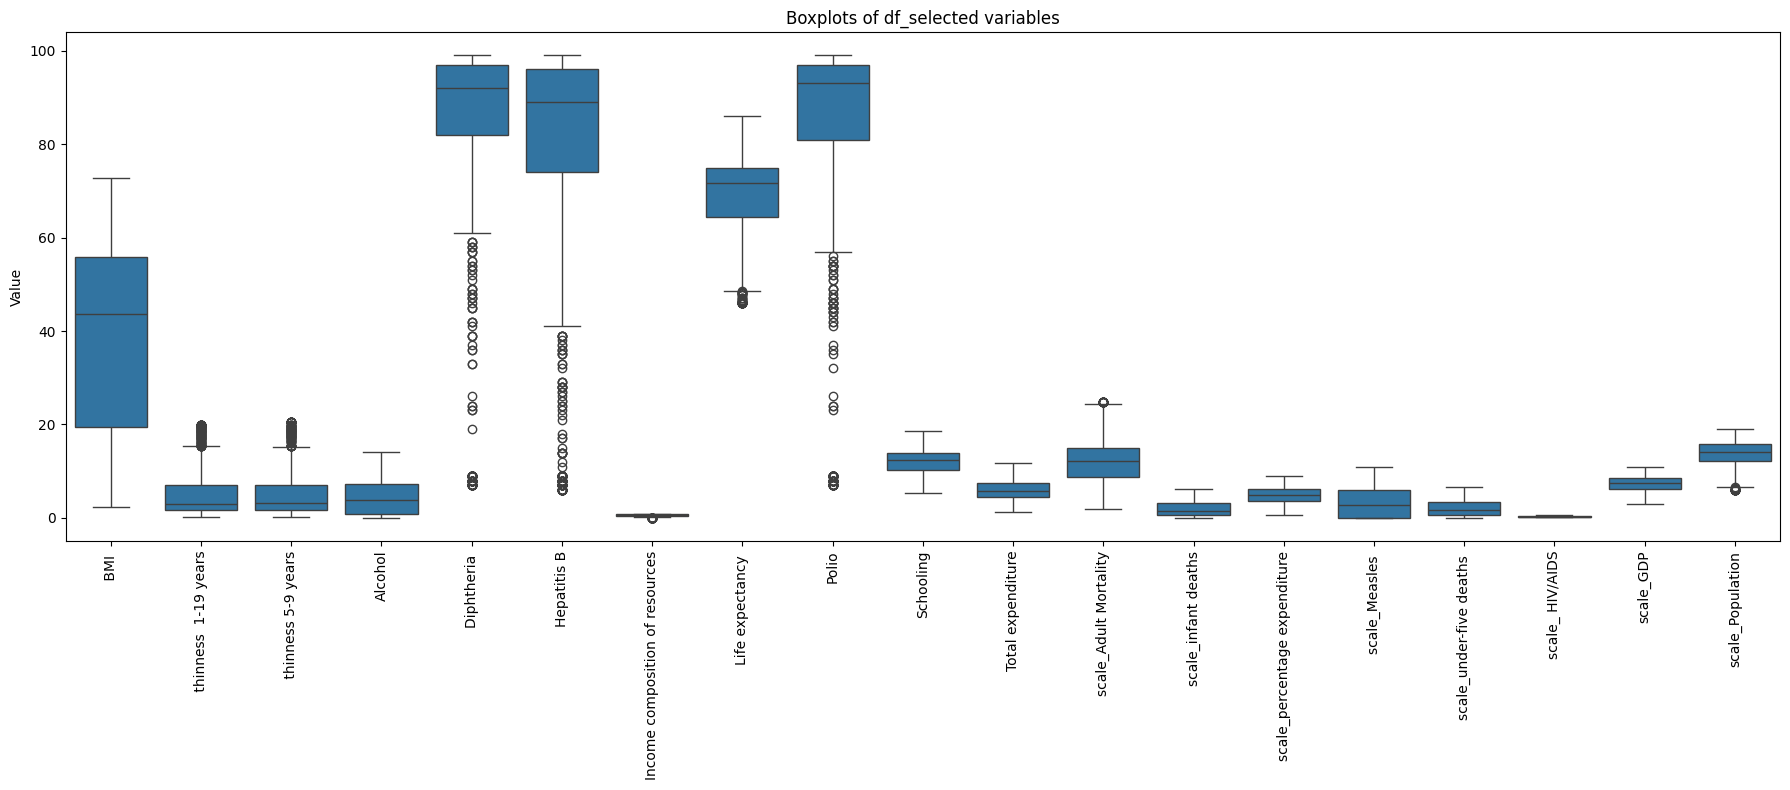

In [102]:
# boxplots for numeric columns in df_selected
num_cols = df_selected_outliers.select_dtypes(include=[np.number]).columns
melted = df_selected_outliers[num_cols].melt(var_name='variable', value_name='value')

plt.figure(figsize=(18, 8))
sns.boxplot(x='variable', y='value', data=melted)
plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('Value')
plt.title('Boxplots of df_selected variables')
plt.tight_layout()
plt.show()

In [103]:
# prepare numeric feature matrix from df_selected_outliers and compute VIF
X_vif = df_selected_outliers.select_dtypes(include=[np.number]).copy().dropna()

# drop constant / zero-variance columns to avoid infinite VIFs
zero_var = X_vif.columns[X_vif.std() == 0].tolist()
if zero_var:
    X_vif = X_vif.drop(columns=zero_var)

X_const = add_constant(X_vif)

vif_df = pd.DataFrame({
    "Feature": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_df

,Feature,VIF
0,const,453.308679
1,scale_under-five deaths,163.838584
2,scale_infant deaths,155.356512
3,scale_percentage expenditure,8.556358
4,scale_GDP,8.314469
5,thinness 5-9 years,6.987109
6,thinness 1-19 years,6.977177
7,Life expectancy,5.505138
8,Schooling,4.194576
9,Income composition of resources,3.290677


In [104]:
df_selected_outliers.drop(['scale_under-five deaths '], axis=1, inplace=True)
df_selected_outliers["Status"] = df["Status"]

# Modelling

In [105]:
X = df_selected_outliers.drop(columns=["Life expectancy "])
X["Status"] = X["Status"].map({"Developing": 1, "Developed": 0})
y = df_selected_outliers["Life expectancy "]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [106]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [113]:
X_train.columns

Index([' BMI ', ' thinness  1-19 years', ' thinness 5-9 years', 'Alcohol',
       'Diphtheria ', 'Hepatitis B', 'Income composition of resources',
       'Polio', 'Schooling', 'Total expenditure', 'scale_Adult Mortality',
       'scale_infant deaths', 'scale_percentage expenditure', 'scale_Measles ',
       'scale_ HIV/AIDS', 'scale_GDP', 'scale_Population', 'Status'],
      dtype='object')

In [108]:
X_train_scaled

array([[-0.59715016,  0.47080068,  0.42951087, ...,  0.03340701,
         1.14579223,  0.41023228],
       [ 0.86787103, -0.82142221, -0.87136838, ...,  0.31684604,
         0.44542172,  0.41023228],
       [-1.65297578, -0.82142221, -0.82651047, ...,  0.51028894,
         1.1898026 ,  0.41023228],
       ...,
       [ 1.10025371, -0.45869298, -0.44521828, ...,  1.19275953,
         0.37855912, -2.43764338],
       [-0.61735735,  0.83352992,  0.83323202, ...,  0.62105498,
         0.65394975,  0.41023228],
       [-0.80932565, -0.59471644, -0.49007619, ..., -2.48433047,
         0.16072581,  0.41023228]], shape=(1319, 18))

In [109]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Lasso Regression": Lasso(random_state=42),
    "Elastic Net": ElasticNet(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

In [110]:
param_grids = {
    "Linear Regression": {},  # no hyperparameters to tune
    "Ridge Regression": {"alpha": [0.1, 1.0, 10, 50, 100]},
    "Lasso Regression": {"alpha": [0.001, 0.01, 0.1, 1, 10]},
    "Elastic Net": {"alpha": [0.01, 0.1, 1], "l1_ratio": [0.1, 0.5, 0.9]},
    "Decision Tree": {"max_depth": [3, 5, 7, 10, None], "min_samples_split": [2, 5, 10]},
    "Random Forest": {"n_estimators": [100, 200], "max_depth": [5, 10, None], "min_samples_split": [2, 5]},
    "Gradient Boosting": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1], "max_depth": [3, 5]}
}


In [111]:
results = {}
best_mse = float("inf")
best_model_name = None
best_model = None

for name, model in models.items():
    print(f"Running GridSearch for {name}...")
    
    grid = param_grids.get(name, {})
    
    if grid:  # if hyperparameters exist
        search = GridSearchCV(model, param_grid=grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        search.fit(X_train_scaled, y_train)
        best_estimator = search.best_estimator_
    else:
        best_estimator = model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = best_estimator.predict(X_test_scaled)
    
    # Metrics
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"RMSE": rmse, "R2": r2, "Model": best_estimator}
    
    # Track best model
    if rmse < best_mse:
        best_mse = rmse
        best_model_name = name
        best_model = best_estimator

    
    print(f"{name} — RMSE: {rmse:.4f}, R2: {r2:.4f}")
    if grid:
        print(f"  Best Parameters: {search.best_params_}\n")

print(f"Best model overall: {best_model_name} with RMSE={best_mse:.4f}")

joblib.dump(best_model, '../models/best_life_expectancy_model.pkl')
joblib.dump(scaler, '../models/life_expectancy_scaler.pkl')


Running GridSearch for Linear Regression...
Linear Regression — RMSE: 3.5944, R2: 0.8148
Running GridSearch for Ridge Regression...
Ridge Regression — RMSE: 3.5894, R2: 0.8153
  Best Parameters: {'alpha': 10}

Running GridSearch for Lasso Regression...
Lasso Regression — RMSE: 3.5801, R2: 0.8163
  Best Parameters: {'alpha': 0.01}

Running GridSearch for Elastic Net...
Elastic Net — RMSE: 3.5874, R2: 0.8155
  Best Parameters: {'alpha': 0.01, 'l1_ratio': 0.1}

Running GridSearch for Decision Tree...
Decision Tree — RMSE: 2.4739, R2: 0.9123
  Best Parameters: {'max_depth': 10, 'min_samples_split': 10}

Running GridSearch for Random Forest...
Random Forest — RMSE: 1.8426, R2: 0.9513
  Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Running GridSearch for Gradient Boosting...
Gradient Boosting — RMSE: 1.9303, R2: 0.9466
  Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Best model overall: Random Forest with RMSE=1.8426


['../models/life_expectancy_scaler.pkl']

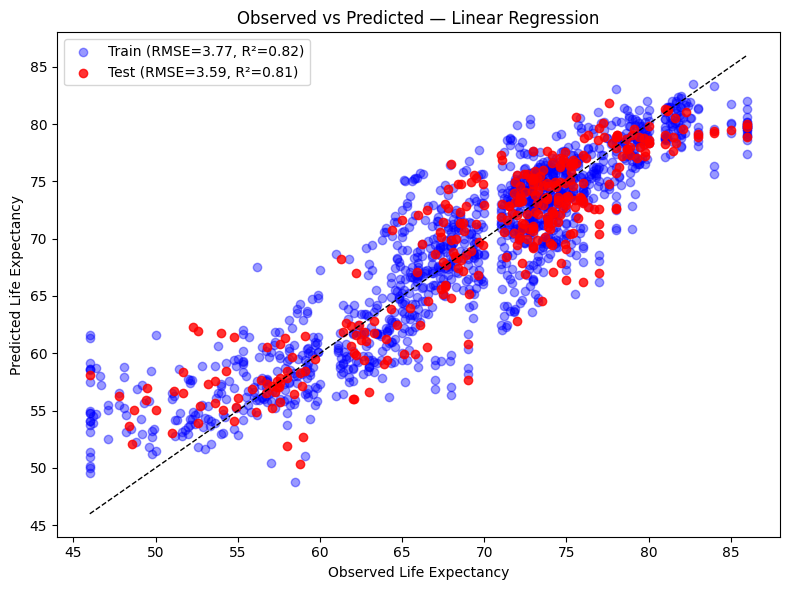

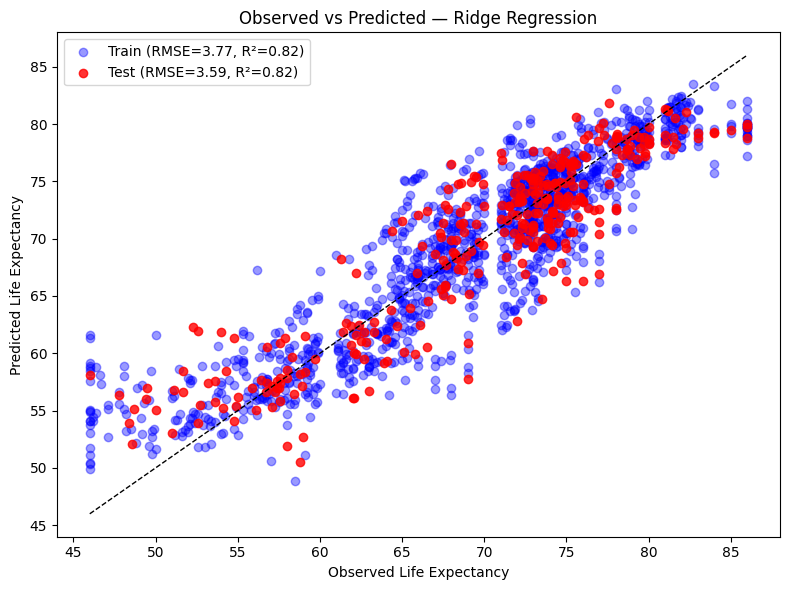

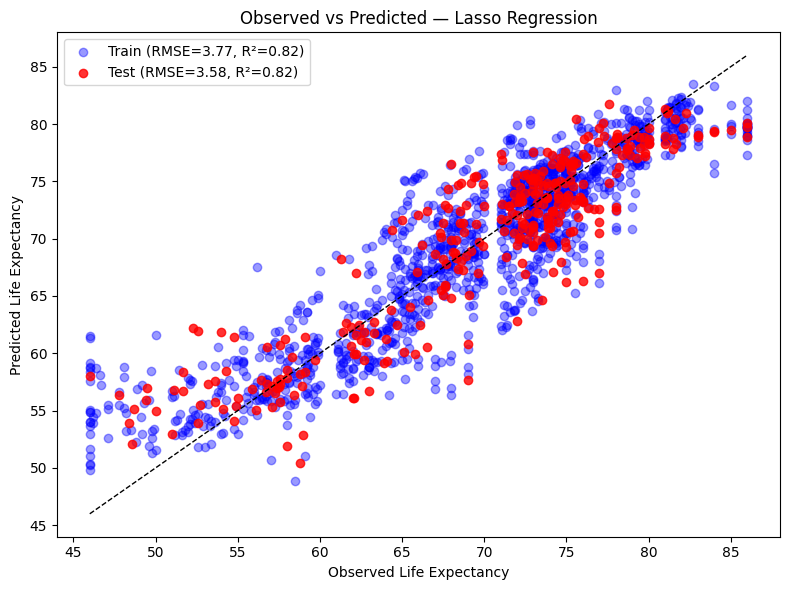

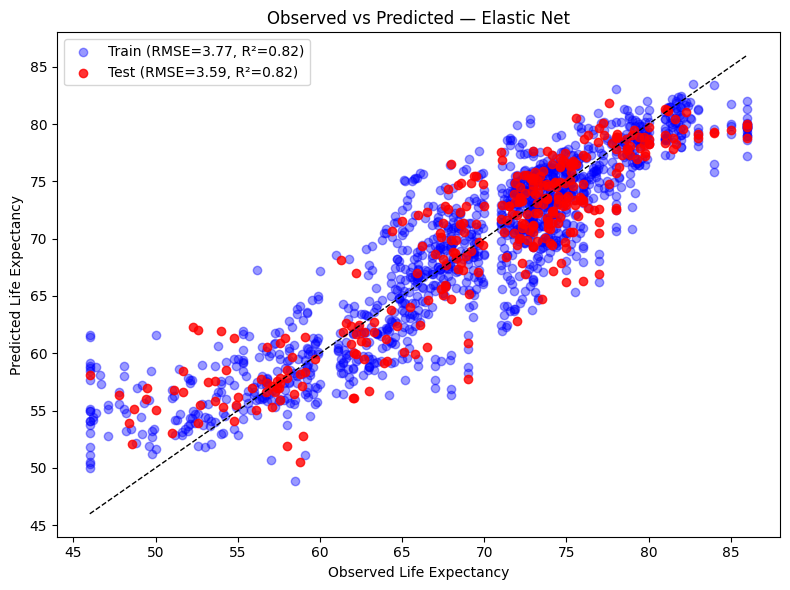

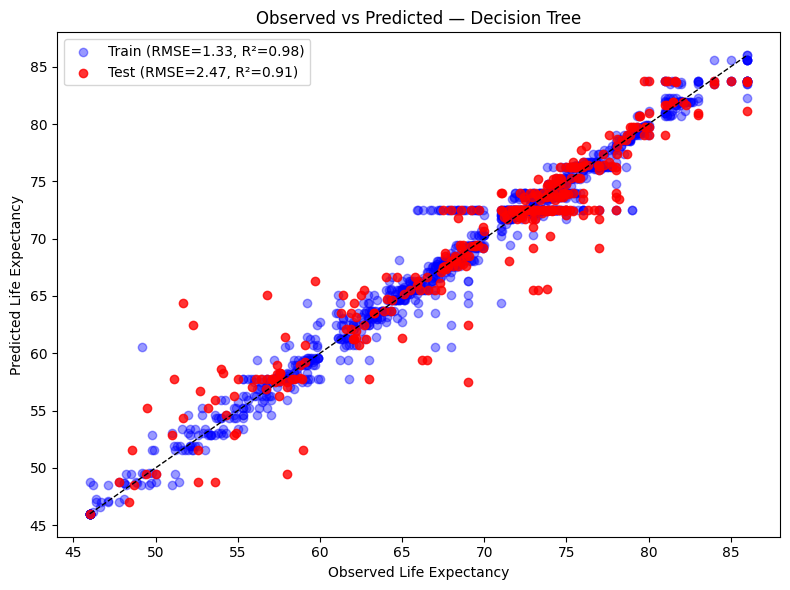

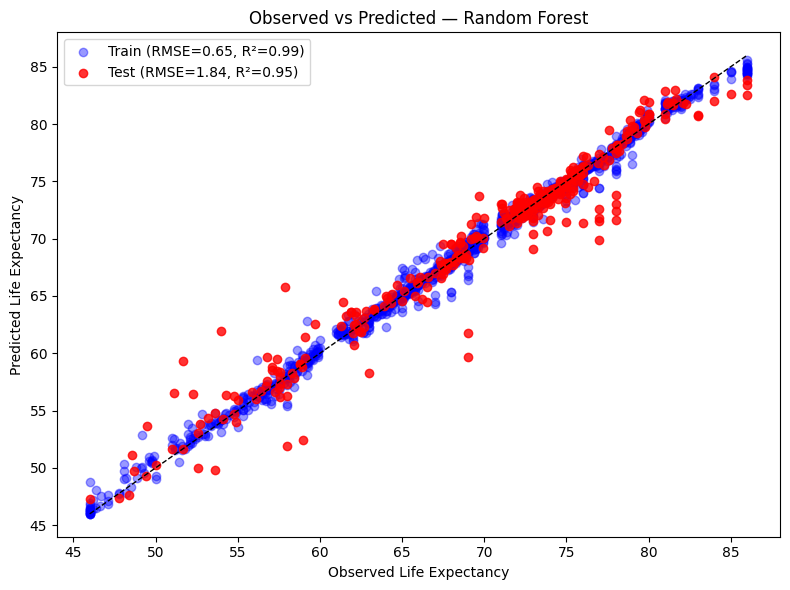

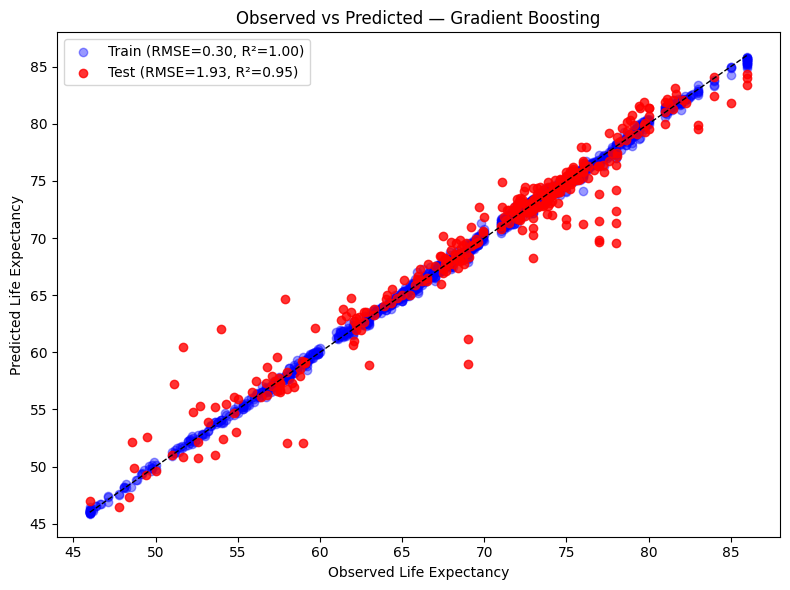

In [112]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Loop through each model
for name, info in results.items():
    model = info["Model"]
    
    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Compute metrics
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2_train = r2_score(y_train, y_train_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_test = r2_score(y_test, y_test_pred)
    
    # Create figure
    plt.figure(figsize=(8, 6))
    
    # Plot train
    plt.scatter(y_train, y_train_pred, color="blue", alpha=0.4, label=f"Train (RMSE={rmse_train:.2f}, R²={r2_train:.2f})")
    # Plot test
    plt.scatter(y_test, y_test_pred, color="red", alpha=0.8, label=f"Test (RMSE={rmse_test:.2f}, R²={r2_test:.2f})")
    
    # Reference line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
    
    # Labels and title
    plt.xlabel("Observed Life Expectancy")
    plt.ylabel("Predicted Life Expectancy")
    plt.title(f"Observed vs Predicted — {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()
